In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\bonag\OneDrive\Documents\Retail_Market_Basket_Analysis\Basket.csv")

In [3]:
df.head()

,Processed column 0,Processed column 1,Processed column 2,Processed column3,Processed column4,Processed column5,Processed column6,Processed column7,Processed column8,Processed column9,Processed column10
0,whole milk,pastry,salty snack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sausage,whole milk,semi-finished bread,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,soda,pickled vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,canned beer,misc. beverages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sausage,hygiene articles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['Processed column 0', 'Processed column 1', 'Processed column 2',
       ' Processed column3', 'Processed column4', 'Processed column5',
       'Processed column6', 'Processed column7', 'Processed column8',
       'Processed column9', 'Processed column10'],
      dtype='str')

In [5]:
df.sample(5)

,Processed column 0,Processed column 1,Processed column 2,Processed column3,Processed column4,Processed column5,Processed column6,Processed column7,Processed column8,Processed column9,Processed column10
10468,curd,other vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5248,onions,citrus fruit,white bread,dessert,shopping bags,NaN,NaN,NaN,NaN,NaN,NaN
8317,berries,other vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8668,beef,other vegetables,bottled water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9666,frankfurter,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(14963, 11)

In [7]:
transactions = []

for i in range(len(df)):
    transaction = []

    for item in df.iloc[i]:
        if pd.notna(item):
            transaction.append(str(item))

    transactions.append(transaction)

print(transactions[:5])

[['whole milk', 'pastry', 'salty snack'], ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['soda', 'pickled vegetables'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles']]


In [8]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.021386,frozenset({UHT-milk})
1,0.033950,frozenset({beef})
2,0.021787,frozenset({berries})
3,0.045312,frozenset({bottled beer})
4,0.060683,frozenset({bottled water})


In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

In [11]:
rules.shape

(0, 14)

In [12]:
frequent_itemsets = apriori(
    basket,
    min_support=0.005,
    use_colnames=True
)

frequent_itemsets.shape

(126, 2)

In [13]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

rules.shape

(19, 14)

In [14]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].sort_values(
           by='lift',
           ascending=False
       ).head(10)

,antecedents,consequents,support,confidence,lift
5,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
0,frozenset({bottled beer}),frozenset({whole milk}),0.007151,0.157817,0.999330
14,frozenset({sausage}),frozenset({whole milk}),0.008955,0.148394,0.939663
7,frozenset({newspapers}),frozenset({whole milk}),0.005614,0.144330,0.913926
4,frozenset({domestic eggs}),frozenset({whole milk}),0.005280,0.142342,0.901341
6,frozenset({frankfurter}),frozenset({whole milk}),0.005280,0.139823,0.885388
11,frozenset({pork}),frozenset({whole milk}),0.005012,0.135135,0.855703
10,frozenset({pip fruit}),frozenset({whole milk}),0.006616,0.134877,0.854071
3,frozenset({citrus fruit}),frozenset({whole milk}),0.007151,0.134591,0.852259
15,frozenset({shopping bags}),frozenset({whole milk}),0.006349,0.133427,0.844887


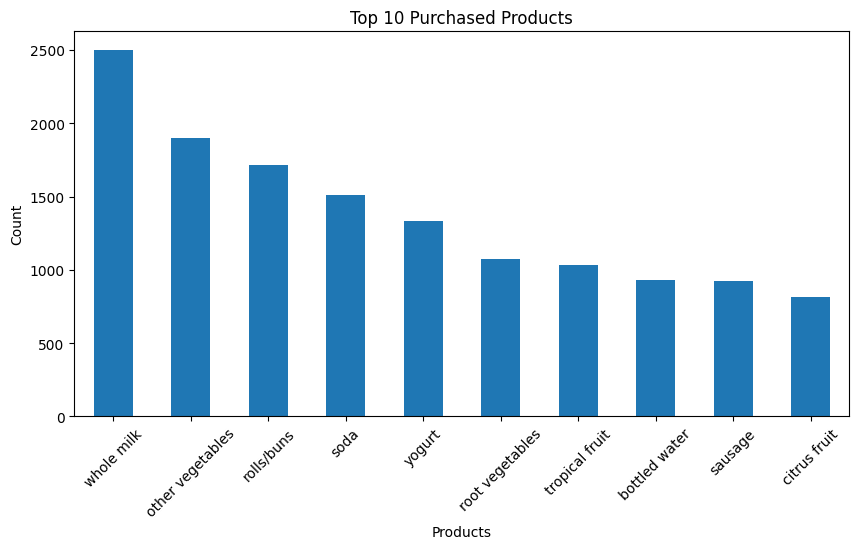

In [15]:
all_items = []

for transaction in transactions:
    all_items.extend(transaction)

top_products = pd.Series(all_items).value_counts().head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Purchased Products")
plt.xlabel("Products")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

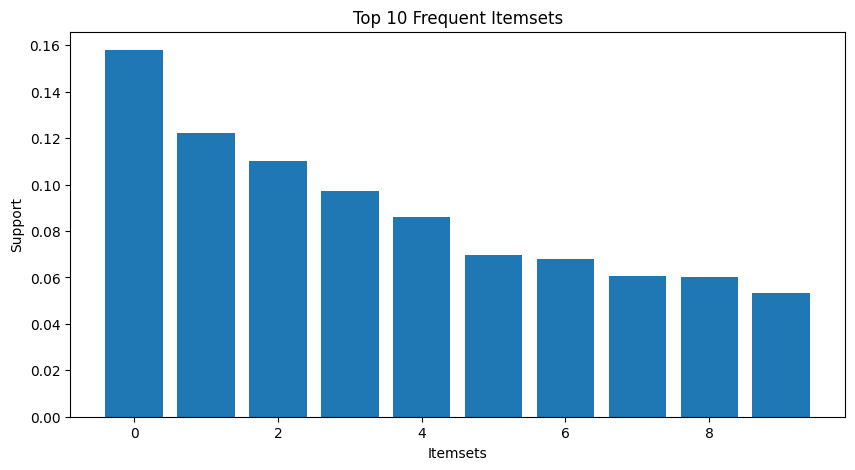

In [16]:
top_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(range(len(top_itemsets)), top_itemsets['support'])
plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.show()

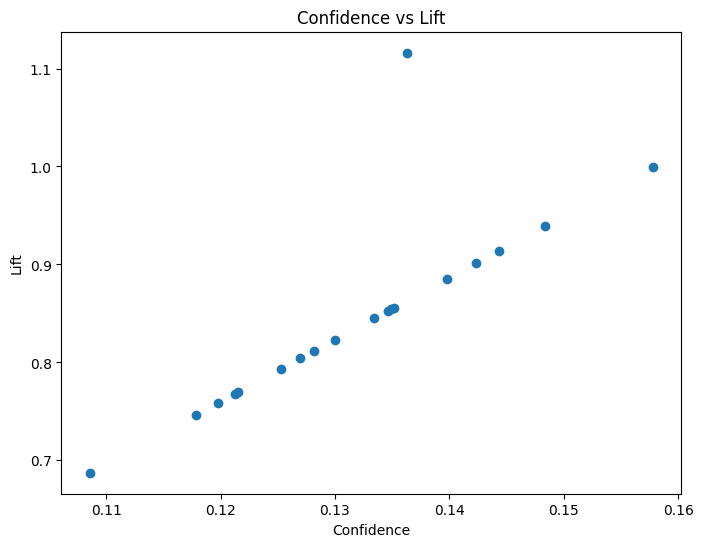

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules['confidence'],
    rules['lift']
)

plt.title("Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

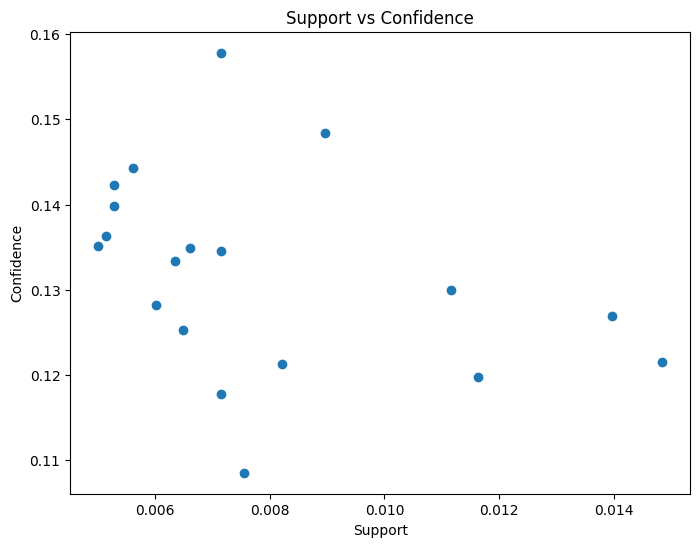

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

product_counts = pd.Series(all_items).value_counts().head(20)

plt.figure(figsize=(12,6))
product_counts.plot(kind='bar')
plt.title("Top 20 Product Frequencies")
plt.xlabel("Products")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

# Insights

1. A total of 14,963 retail transactions were analyzed.
2. The dataset contained 167 unique products.
3. The Apriori algorithm generated 126 frequent itemsets.
4. A total of 19 association rules were discovered.
5. Whole milk appeared in multiple association rules, indicating high customer demand.

# Conclusion

The Retail Market Basket Analysis project successfully identified customer purchasing patterns using the Apriori algorithm. The generated association rules can help retailers improve product placement, inventory management, and sales strategies.

# Future Scope

1. Use larger datasets.
2. Develop recommendation systems.
3. Create Power BI dashboards.
4. Implement real-time analytics.